# CNN з нуля — Face Anti-Spoofing

Власна архітектура CNN написана на PyTorch без pretrained вагів.

**Архітектура:** 4 ConvBlock (Conv→BN→ReLU→MaxPool) + GlobalAvgPool + FC

**Вхід:** кадри з `datasets/frames/`

**Виходи:** `models/cnn_scratch_best.pth`

## Імпорти

In [2]:
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
    
print(f'PyTorch: {torch.__version__}  |  Device: {DEVICE}')

PyTorch: 2.11.0  |  Device: mps


## Конфігурація

In [3]:
DATASET_ROOT = Path('./datasets')
FRAMES_ROOT  = Path('./datasets/frames')
MODELS_DIR   = Path('./models')
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE    = 256
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 1e-3
WEIGHT_DECAY= 1e-4
NUM_WORKERS = 0

PROTO_DIR = DATASET_ROOT / 'protocols'

PROTOCOLS = {
    'grandtest': ('attack-grandtest-allsupports-{}.txt', 'real-{}.txt'),
    'print':     ('attack-print-allsupports-{}.txt',     'real-{}.txt'),
    'mobile':    ('attack-mobile-allsupports-{}.txt',    'real-{}.txt'),
    'highdef':   ('attack-highdef-allsupports-{}.txt',   'real-{}.txt'),
    'fixed':     ('attack-grandtest-fixed-{}.txt',       'real-{}.txt'),
    'hand':      ('attack-grandtest-hand-{}.txt',        'real-{}.txt'),
}
print('Конфігурація готова')

Конфігурація готова


## Dataset клас

In [4]:
def read_protocol(proto_file):
    pf = Path(proto_file)
    if not pf.exists():
        print(f'[!] Не знайдено: {pf}')
        return []
    with open(pf) as f:
        return [l.strip() for l in f if l.strip()]

def video_to_frames_dir(video_rel_path):
    p = Path(video_rel_path)
    return FRAMES_ROOT / p.parent / p.stem


class FaceDataset(Dataset):
    """
    Завантажує кадри з frames/ за списком відео з протокольних файлів.
    label=0 (real), label=1 (attack)
    """
    def __init__(self, attack_paths, real_paths, transform=None):
        self.samples = []   # (frame_path, label, video_idx)
        self.transform = transform
        video_idx = 0

        for vpath in real_paths:
            fdir = video_to_frames_dir(vpath)
            for fp in sorted(fdir.glob('*.jpg')) if fdir.exists() else []:
                self.samples.append((fp, 0, video_idx))
            video_idx += 1

        for vpath in attack_paths:
            fdir = video_to_frames_dir(vpath)
            for fp in sorted(fdir.glob('*.jpg')) if fdir.exists() else []:
                self.samples.append((fp, 1, video_idx))
            video_idx += 1

        self.n_videos = video_idx
        print(f'  Dataset: {len(self.samples)} кадрів, {video_idx} відео')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label, vid_idx = self.samples[idx]
        img = cv2.imread(str(fpath))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, label, vid_idx


# Аугментації
# ColorJitter прибрано: агресивна корекція кольору/яскравості може маскувати
# spoof-cues (моарé, субпікселі, зсуви gamut-у принтера) — саме те, що модель має навчитися ловити.
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print('Dataset клас готовий')


Dataset клас готовий


## Архітектура CNN

In [5]:
class ConvBlock(nn.Module):
    """Conv → BatchNorm → ReLU → MaxPool"""
    def __init__(self, in_ch, out_ch, kernel=3, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=kernel//2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class SpoofCNN(nn.Module):
    """
    CNN для face anti-spoofing написана з нуля.
    Вхід: (B, 3, 128, 128)
    """
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),   # -> 32 x 64 x 64
            ConvBlock(32,  64),   # -> 64 x 32 x 32
            ConvBlock(64,  128),  # -> 128 x 16 x 16
            ConvBlock(128, 256),  # -> 256 x 8 x 8
        )
        self.pool = nn.AdaptiveAvgPool2d(1)  # -> 256 x 1 x 1
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = SpoofCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Параметри: {total_params:,} всього, {trainable:,} trainable')
print(model)

Параметри: 422,050 всього, 422,050 trainable
SpoofCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0

## Завантаження даних

In [6]:
print('Train set:')
train_ds = FaceDataset(
    attack_paths=read_protocol(PROTO_DIR / 'attack-grandtest-allsupports-train.txt'),
    real_paths  =read_protocol(PROTO_DIR / 'real-train.txt'),
    transform   =train_transform
)

print('Devel set:')
devel_ds = FaceDataset(
    attack_paths=read_protocol(PROTO_DIR / 'attack-grandtest-allsupports-devel.txt'),
    real_paths  =read_protocol(PROTO_DIR / 'real-devel.txt'),
    transform   =val_transform
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
devel_loader = DataLoader(devel_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'\nTrain batches: {len(train_loader)} | Devel batches: {len(devel_loader)}')

Train set:
  Dataset: 3575 кадрів, 360 відео
Devel set:
  Dataset: 3564 кадрів, 360 відео

Train batches: 112 | Devel batches: 112


## Навчання

In [7]:
# ---------- Допоміжні функції для video-level EER (для model selection) ----------
def _compute_eer_value(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2)

def _devel_video_eer(loader):
    """Проганяє devel-loader, усереднює score'и по відео, рахує EER."""
    model.eval()
    all_probs, all_labels, all_vids = [], [], []
    with torch.no_grad():
        for imgs, labels, vid_idx in loader:
            probs = torch.softmax(model(imgs.to(DEVICE)), dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs); all_labels.extend(labels.numpy()); all_vids.extend(vid_idx.numpy())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_vids   = np.array(all_vids)
    vs, vl = [], []
    for v in np.unique(all_vids):
        m = all_vids == v
        vs.append(all_probs[m].mean()); vl.append(all_labels[m][0])
    return _compute_eer_value(np.array(vl), np.array(vs))

# ---------- Class weight для боротьби з дисбалансом real:attack ≈ 1:5 ----------
n_real   = sum(1 for s in train_ds.samples if s[1] == 0)
n_attack = sum(1 for s in train_ds.samples if s[1] == 1)
w_real   = n_attack / n_real if n_real > 0 else 1.0
class_weights = torch.tensor([w_real, 1.0], dtype=torch.float32).to(DEVICE)
print(f'Train: real={n_real} кадрів, attack={n_attack} кадрів → class_weights=[{w_real:.2f}, 1.00]')

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {'train_loss': [], 'train_acc': [], 'devel_loss': [], 'devel_acc': [], 'devel_eer': []}
best_devel_eer = 1.0   # ← вибираємо модель за МІНІМАЛЬНИМ EER на devel, а не за accuracy
best_epoch = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # --- Train ---
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for imgs, labels, _ in tqdm(train_loader, desc=f'Epoch {epoch:02d}/{NUM_EPOCHS} [train]', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * imgs.size(0)
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += imgs.size(0)

    # --- Devel (loss + acc + video-level EER) ---
    model.eval()
    dv_loss, dv_correct, dv_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels, _ in devel_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            dv_loss += loss.item() * imgs.size(0)
            dv_correct += (out.argmax(1) == labels).sum().item()
            dv_total   += imgs.size(0)
    dv_eer = _devel_video_eer(devel_loader)

    scheduler.step()

    tr_acc = tr_correct / tr_total
    dv_acc = dv_correct / dv_total
    history['train_loss'].append(tr_loss / tr_total)
    history['train_acc'].append(tr_acc)
    history['devel_loss'].append(dv_loss / dv_total)
    history['devel_acc'].append(dv_acc)
    history['devel_eer'].append(dv_eer)

    # ← Ключова зміна: best_epoch за EER, а не accuracy
    if dv_eer < best_devel_eer:
        best_devel_eer = dv_eer
        best_epoch = epoch
        torch.save(model.state_dict(), MODELS_DIR / 'cnn_scratch_best.pth')

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  '
          f'train loss={tr_loss/tr_total:.4f} acc={tr_acc:.4f}  '
          f'devel loss={dv_loss/dv_total:.4f} acc={dv_acc:.4f} eer={dv_eer*100:.2f}%'
          f'  {"← best (EER)" if epoch == best_epoch else ""}')

print(f'\nНайкраща модель: epoch {best_epoch}, devel EER={best_devel_eer*100:.2f}%')


Train: real=598 кадрів, attack=2977 кадрів → class_weights=[4.98, 1.00]


Epoch 01/30  train loss=0.1532 acc=0.9407  devel loss=0.1376 acc=0.9394 eer=7.00%  ← best (EER)


Epoch 02/30  train loss=0.1046 acc=0.9594  devel loss=0.0990 acc=0.9602 eer=3.33%  ← best (EER)


Epoch 03/30  train loss=0.0908 acc=0.9639  devel loss=0.0829 acc=0.9649 eer=5.00%  


Epoch 04/30  train loss=0.0889 acc=0.9662  devel loss=0.1192 acc=0.9588 eer=6.33%  


...

Epoch 26/30  train loss=0.0050 acc=0.9986  devel loss=0.0176 acc=0.9924 eer=0.17%  


Epoch 27/30  train loss=0.0037 acc=0.9989  devel loss=0.0125 acc=0.9952 eer=0.00%  


Epoch 28/30  train loss=0.0042 acc=0.9986  devel loss=0.0113 acc=0.9958 eer=0.00%  


Epoch 29/30  train loss=0.0045 acc=0.9986  devel loss=0.0112 acc=0.9961 eer=0.00%  


Epoch 30/30  train loss=0.0040 acc=0.9980  devel loss=0.0121 acc=0.9949 eer=0.00%  

Найкраща модель: epoch 17, devel EER=0.00%


## Криві навчання

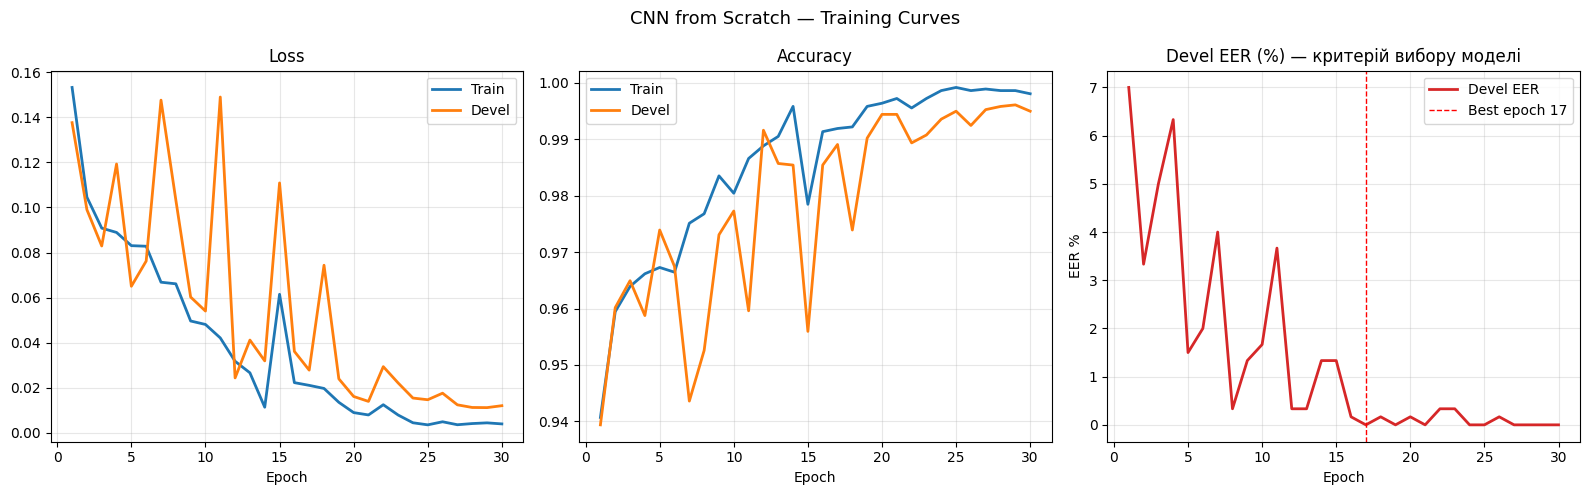

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', lw=2)
axes[0].plot(epochs, history['devel_loss'], label='Devel', lw=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='Train', lw=2)
axes[1].plot(epochs, history['devel_acc'], label='Devel', lw=2)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, [e*100 for e in history['devel_eer']], label='Devel EER', lw=2, color='tab:red')
axes[2].axvline(best_epoch, color='red', ls='--', lw=1, label=f'Best epoch {best_epoch}')
axes[2].set_title('Devel EER (%) — критерій вибору моделі')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('EER %'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('CNN from Scratch — Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('models/cnn_scratch_training.png', dpi=150)
plt.show()


## Оцінка на test set по протоколах

In [9]:
# Завантажуємо найкращі ваги
model.load_state_dict(torch.load(MODELS_DIR / 'cnn_scratch_best.pth', map_location=DEVICE))
model.eval()

def get_video_scores(dataset):
    """Повертає (video_scores, video_labels) через average pooling по кадрах."""
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
    all_probs, all_labels, all_vids = [], [], []
    with torch.no_grad():
        for imgs, labels, vid_idx in loader:
            imgs = imgs.to(DEVICE)
            probs = torch.softmax(model(imgs), dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
            all_vids.extend(vid_idx.numpy())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_vids   = np.array(all_vids)
    v_scores, v_labels = [], []
    for v in np.unique(all_vids):
        mask = all_vids == v
        v_scores.append(all_probs[mask].mean())
        v_labels.append(all_labels[mask][0])
    return np.array(v_scores), np.array(v_labels)

def compute_eer(y_true, y_scores):
    fpr, tpr, ths = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2), float(ths[idx])

def compute_hter(y_true, y_scores, threshold):
    p = (y_scores >= threshold).astype(int)
    return float((p[y_true == 0].mean() + (1 - p[y_true == 1]).mean()) / 2)

# --- Оцінка: для кожного під-протоколу threshold підбирається НА ЙОГО ВЛАСНОМУ devel ---
print('Тест по протоколах (threshold підбирається для кожного під-протоколу окремо на його devel)...')
results = {}
for proto_name, (atk_tpl, real_tpl) in PROTOCOLS.items():
    print(f'\n  === {proto_name} ===')
    # 1) Devel → threshold
    atk_d  = read_protocol(PROTO_DIR / atk_tpl.format('devel'))
    real_d = read_protocol(PROTO_DIR / real_tpl.format('devel'))
    if not atk_d or not real_d:
        print(f'  [!] Пропущено (немає devel-протоколу)')
        continue
    ds_d = FaceDataset(atk_d, real_d, transform=val_transform)
    vs_d, vl_d = get_video_scores(ds_d)
    eer_d, proto_threshold = compute_eer(vl_d, vs_d)
    print(f'  Devel: EER={eer_d*100:.2f}% → threshold={proto_threshold:.4f}')

    # 2) Test
    atk  = read_protocol(PROTO_DIR / atk_tpl.format('test'))
    real = read_protocol(PROTO_DIR / real_tpl.format('test'))
    if not atk or not real:
        continue
    ds = FaceDataset(atk, real, transform=val_transform)
    vs, vl = get_video_scores(ds)
    eer, _ = compute_eer(vl, vs)
    hter   = compute_hter(vl, vs, proto_threshold)
    fpr, tpr, _ = roc_curve(vl, vs)
    results[proto_name] = {
        'n': ds.n_videos,
        'acc': accuracy_score(vl, (vs >= proto_threshold).astype(int)),
        'auc': auc(fpr, tpr), 'eer': eer, 'hter': hter,
        'threshold': proto_threshold,
        'fpr': fpr, 'tpr': tpr, 'vs': vs, 'vl': vl
    }
    print(f'  Test:  EER={eer*100:.2f}%  HTER={hter*100:.2f}%  AUC={auc(fpr, tpr):.4f}')


Тест по протоколах (threshold підбирається для кожного під-протоколу окремо на його devel)...

  === grandtest ===
  Dataset: 3564 кадрів, 360 відео
  Devel: EER=0.00% → threshold=0.2392
  Dataset: 4714 кадрів, 480 відео
  Test:  EER=1.51%  HTER=1.26%  AUC=0.9991

  === print ===
  Dataset: 1185 кадрів, 120 відео
  Devel: EER=0.00% → threshold=0.2392
  Dataset: 1590 кадрів, 160 відео
  Test:  EER=3.75%  HTER=1.25%  AUC=0.9987

  === mobile ===
  Dataset: 1790 кадрів, 180 відео
  Devel: EER=0.00% → threshold=0.5563
  Dataset: 2336 кадрів, 240 відео
  Test:  EER=0.32%  HTER=0.32%  AUC=0.9997

  === highdef ===
  Dataset: 1789 кадрів, 180 відео
  Devel: EER=0.00% → threshold=0.7867
  Dataset: 2372 кадрів, 240 відео
  Test:  EER=1.88%  HTER=3.75%  AUC=0.9986

  === fixed ===
  Dataset: 2080 кадрів, 210 відео
  Devel: EER=0.00% → threshold=0.5474
  Dataset: 2744 кадрів, 280 відео
  Test:  EER=0.51%  HTER=1.02%  AUC=0.9994

  === hand ===
  Dataset: 2084 кадрів, 210 відео
  Devel: EER=0.00% 

## Результати

In [11]:
print('\n' + '='*60)
print(f'{"Протокол":<12} {"N":>5} {"Acc":>7} {"AUC":>7} {"EER%":>7} {"HTER%":>8}')
print('-'*60)
for name, r in results.items():
    print(f'{name:<12} {r["n"]:>5} {r["acc"]:>7.4f} {r["auc"]:>7.4f} '
          f'{r["eer"]*100:>6.2f}% {r["hter"]*100:>7.2f}%')
print('='*60)


Протокол         N     Acc     AUC    EER%    HTER%
------------------------------------------------------------
grandtest      480  0.9790  0.9991   1.51%    1.26%
print          160  0.9875  0.9987   3.75%    1.25%
mobile         240  0.9958  0.9997   0.32%    0.32%
highdef        240  0.9500  0.9986   1.88%    3.75%
fixed          280  0.9856  0.9994   0.51%    1.02%
hand           280  0.9750  0.9987   1.88%    1.75%


## ROC криві

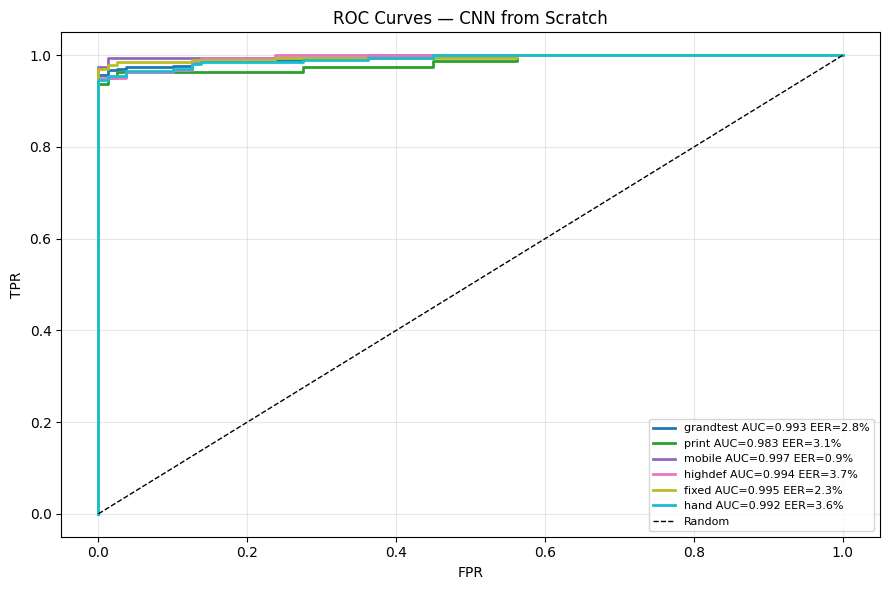

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), c in zip(results.items(), colors):
    ax.plot(r['fpr'], r['tpr'], color=c, lw=2,
            label=f'{name} AUC={r["auc"]:.3f} EER={r["eer"]*100:.1f}%')
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — CNN from Scratch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('models/cnn_scratch_roc.png', dpi=150)
plt.show()

## Confusion Matrix (grandtest)

In [ ]:
r = results['grandtest']
cm = confusion_matrix(r['vl'], (r['vs'] >= r['threshold']).astype(int))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real','Attack'], yticklabels=['Real','Attack'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — CNN Scratch (grandtest, test) threshold={r["threshold"]:.3f}')
plt.tight_layout()
plt.savefig('models/cnn_scratch_cm.png', dpi=150)
plt.show()


## Збереження результатів

In [ ]:
import json
save_data = {
    'best_epoch': best_epoch,
    'best_devel_eer': float(best_devel_eer),
    'results': {k: {m: float(v) if not isinstance(v, np.ndarray) else v.tolist()
                    for m, v in r.items() if m not in ('fpr','tpr','vs','vl')}
                for k, r in results.items()}
}
with open(MODELS_DIR / 'cnn_scratch_results.json', 'w') as f:
    json.dump(save_data, f, indent=2)
print('Результати збережено: models/cnn_scratch_results.json')
print('Модель збережена:     models/cnn_scratch_best.pth')
